<a href="https://colab.research.google.com/github/MuhammadNihalImran/ML_Lab_Tasks/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vikasukani/parkinsons-disease-data-set")

print("Path to dataset files:", path)

100%|██████████| 15.6k/15.6k [00:00<00:00, 22.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vikasukani/parkinsons-disease-data-set/versions/1


In [2]:
import os

print(os.listdir(path))

['parkinsons.data']


In [6]:
import pandas as pd
import os

# The dataset contains 'parkinsons.data' instead of 'parkinsons.csv'
file_path = os.path.join(path, "parkinsons.data")

df = pd.read_csv(file_path)

df.shape

(195, 24)

In [8]:
val_nul = df.isnull().sum()
print(val_nul[val_nul > 0])

Series([], dtype: int64)


In [12]:
print(df.select_dtypes(include='object').dtypes)

name    object
dtype: object


In [16]:
X = df.drop(["status", "name"], axis=1)
y = df["status"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Model
model = SVC()

# Parameters to test
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best cross-validation score
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.8590725806451613


In [20]:
# Best model
best_model = grid_search.best_estimator_

# Prediction on test data
y_pred = best_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1
 1 0]


In [21]:
print("Actual:   ", y_test.values)
print("Predicted:", y_pred)

Actual:    [0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1
 1 0]
Predicted: [1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1
 1 0]


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9230769230769231
Precision: 0.9333333333333333
Recall   : 0.9655172413793104
F1-Score : 0.9491525423728814


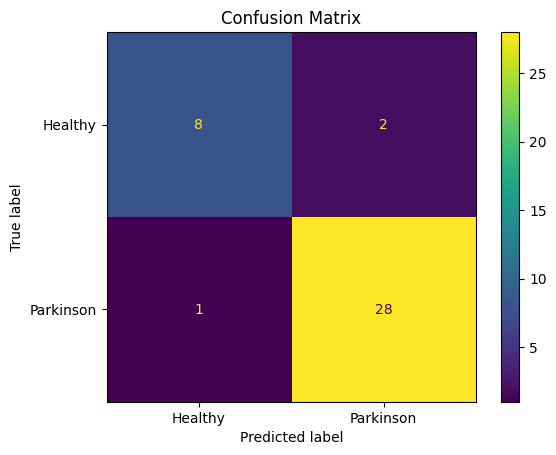

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Parkinson"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()